# Name : Muhammad Hassan Khalid
# 21L-5692

# TASK A

# Importing The Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reading the data in a csv file

In [2]:
data = pd.read_csv('Mall_Customers.csv')

## Data Shape

In [3]:
print("Shape:", data.shape)

Shape: (200, 5)


## Data Features

In [4]:
print("\nFeatures:", data.columns)


Features: Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


## Data Description

In [5]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Data Information

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Visualizing some data points

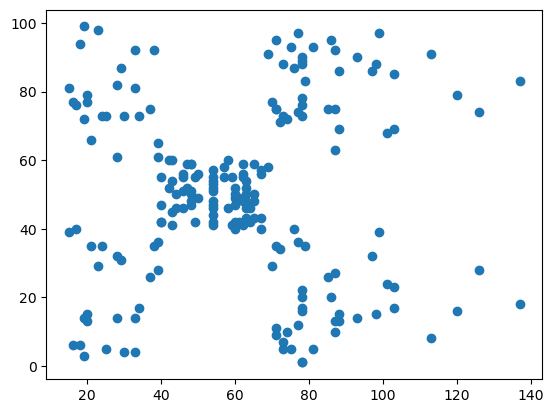

In [7]:
x = data['Annual Income (k$)']
y = data['Spending Score (1-100)']

plt.scatter(x, y)

plt.show()

# Determining the number of clusters using elbow method

D:\Anaconda\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


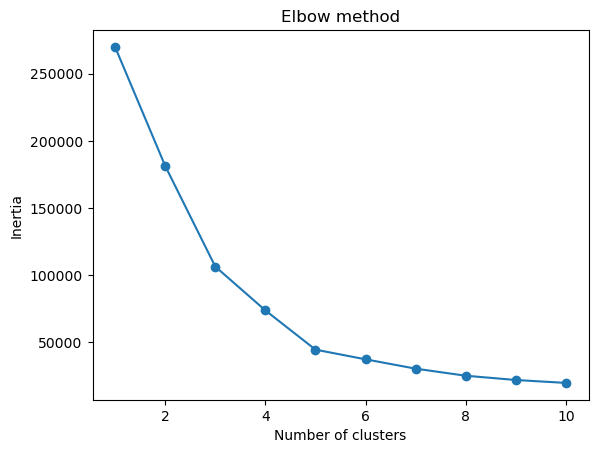

In [8]:
from sklearn.cluster import KMeans

x = data['Annual Income (k$)']
y = data['Spending Score (1-100)']

data = list(zip(x, y))
inertias = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Applying Agglomerative Clustering

In [9]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np

data = list(zip(x, y))

clustering = AgglomerativeClustering(n_clusters = 5).fit(data)

print(clustering.labels_)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 1 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 1 2 0 2 1 2
 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2]


# Visualize the result

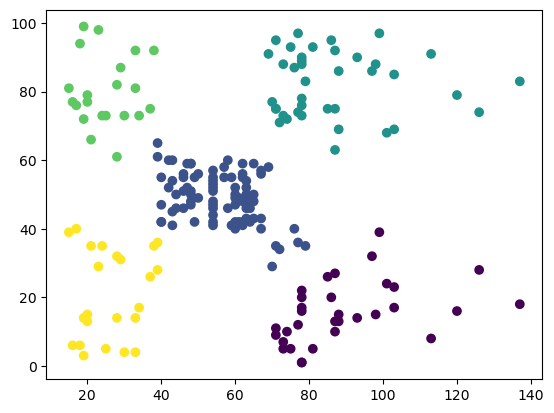

In [10]:
plt.scatter(x, y, c=clustering.labels_)

plt.show()

# TASK B

# Importing Libraires

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import seaborn as sns

# Reading the data in a csv file

In [12]:
data = pd.read_csv('Mall_Customers.csv')

# Visualizing some data points

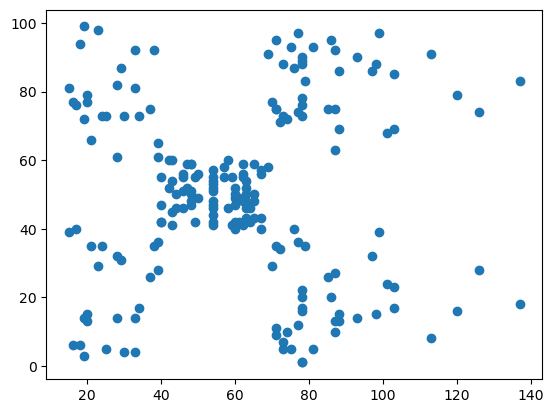

In [13]:
plt.scatter(data['Annual Income (k$)'],data['Spending Score (1-100)'])

# Applying Agglomerative Clustering

In [14]:
import numpy as np

def euclidean_distance(x, y):
    # Compute the Euclidean distance between two points
    return np.sqrt(np.sum((x - y) ** 2))

def agglomerative_clustering(X, n_clusters):
    # Convert the input to a numpy array
    X = np.array(X)
    
    # Compute the pairwise distances between data points
    n = len(X)
    distances = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            distances[i][j] = euclidean_distance(X[i], X[j])
            distances[j][i] = distances[i][j]
            
    # Initialize the clusters
    clusters = [[i] for i in range(n)]
    
    # Merge the clusters until the desired number of clusters is reached
    while len(clusters) > n_clusters:
        # Find the indices of the two closest clusters
        min_dist = np.inf
        for i in range(len(clusters)):
            for j in range(i+1, len(clusters)):
                dist = np.min([distances[a][b] for a in clusters[i] for b in clusters[j]])
                if dist < min_dist:
                    min_dist = dist
                    merge_indices = (i, j)
        
        # Merge the two closest clusters
        clusters[merge_indices[0]] += clusters[merge_indices[1]]
        clusters.pop(merge_indices[1])
    
    # Assign labels to the data points based on the final clusters
    labels = np.zeros(n, dtype=int)
    for i, cluster in enumerate(clusters):
        for j in cluster:
            labels[j] = i
    
    return labels


In [15]:
x = data['Annual Income (k$)']
y = data['Spending Score (1-100)']

data = list(zip(x, y))

In [16]:
clustering = agglomerative_clustering(data , n_clusters = 5)

print(clustering)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 1 2 1 2 3 4]


# Visualize the result

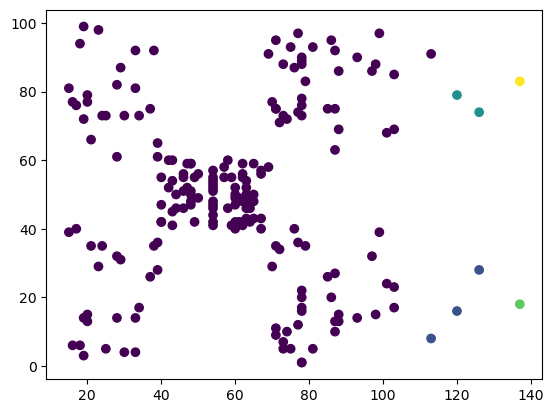

In [17]:
plt.scatter(x, y, c=clustering)

plt.show()